In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/EasyVisa%20(1).csv"

In [3]:
df = pd.read_csv(url)


In [10]:
rows, columns = df.shape

# Print the number of rows and columns
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 25480
Number of columns: 12


In [11]:
print("--- dtypes ---")
print(df.dtypes)

--- dtypes ---
case_id                   object
continent                 object
education_of_employee     object
has_job_experience        object
requires_job_training     object
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
prevailing_wage          float64
unit_of_wage              object
full_time_position        object
case_status               object
dtype: object


In [6]:
print("\n--- first 5 rows ---")
display(df.head())


--- first 5 rows ---


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [7]:
print("\n--- missing values by column ---")
print(df.isnull().sum())


--- missing values by column ---
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [8]:
print("\n--- target distribution (case_status) ---")
print(df['case_status'].value_counts(dropna=False))


--- target distribution (case_status) ---
case_status
Certified    17018
Denied        8462
Name: count, dtype: int64


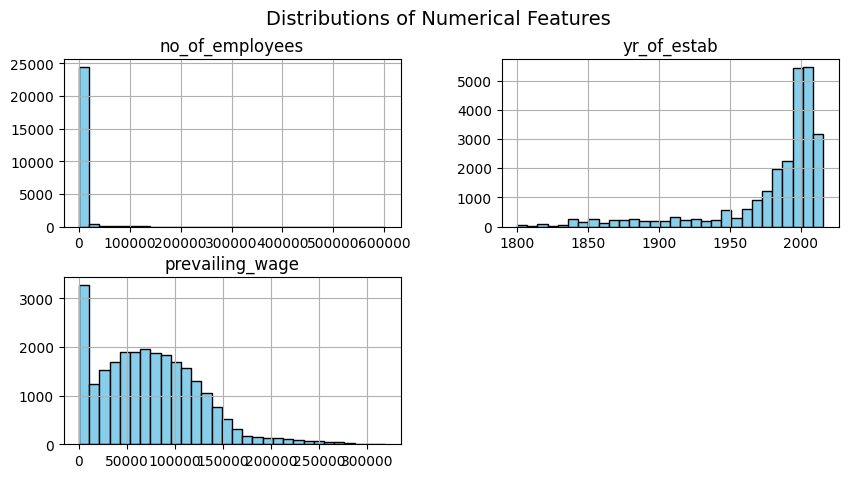

In [15]:

# checking distribution of numerical columns to see if any are skewed or have outliers.
numeric_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

df[numeric_cols].hist(bins=30, figsize=(10, 5), color='skyblue', edgecolor='black')
plt.suptitle("Distributions of Numerical Features", fontsize=14)
plt.show()


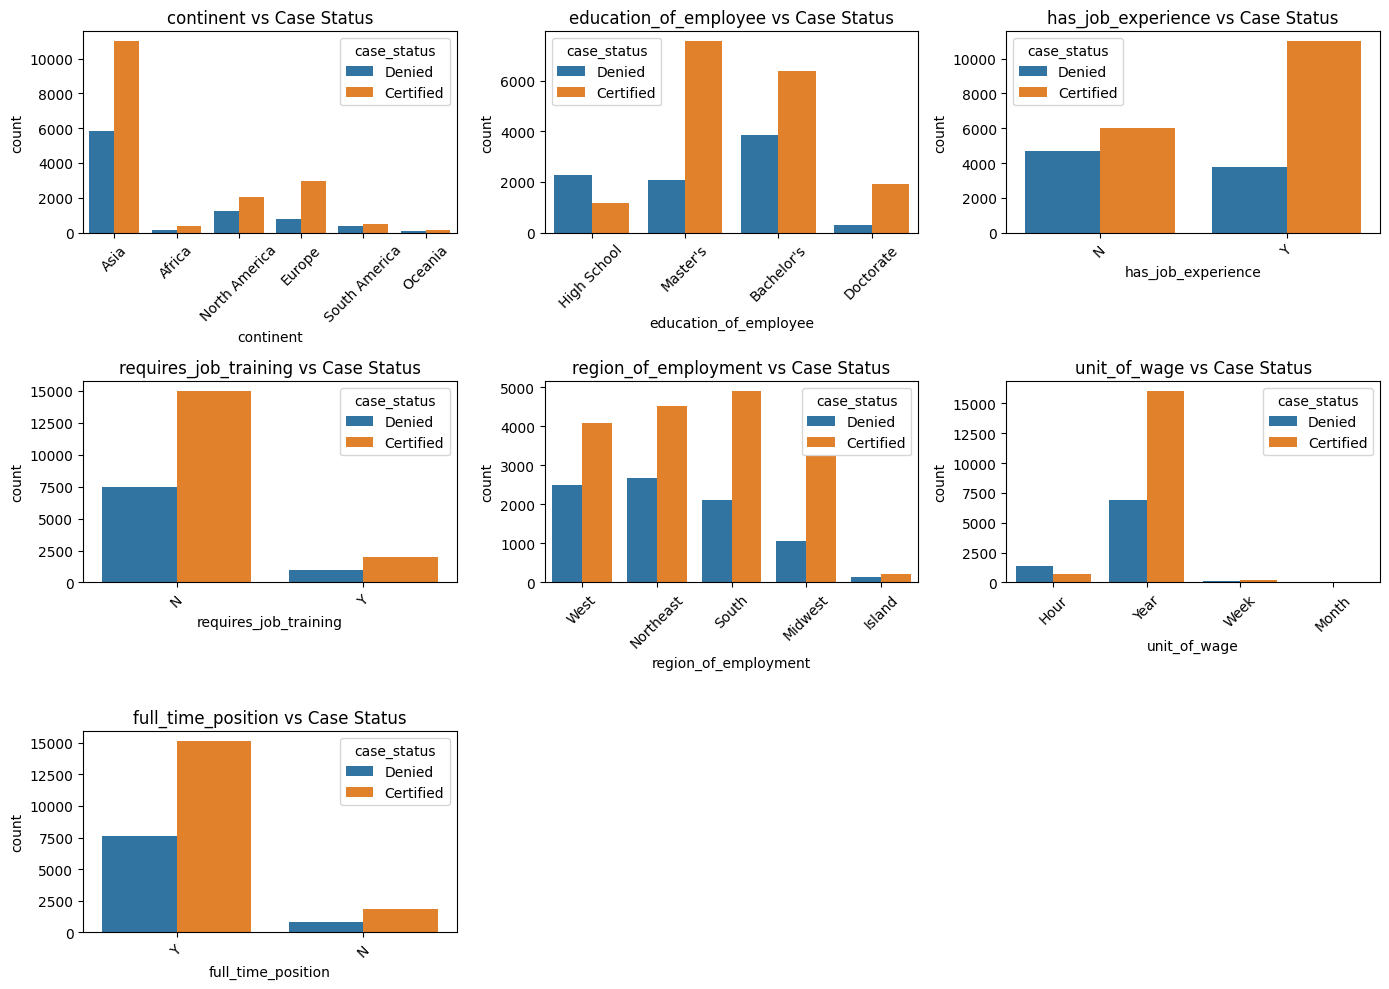

In [17]:
categorical_cols = ['continent', 'education_of_employee', 'has_job_experience',
                    'requires_job_training', 'region_of_employment',
                    'unit_of_wage', 'full_time_position']

plt.figure(figsize=(14, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='case_status', data=df)
    plt.title(f'{col} vs Case Status')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [19]:
# List of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Display unique value counts for each categorical variable
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-" * 50)



Column: case_id
case_id
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
EZYV05       1
            ..
EZYV25476    1
EZYV25477    1
EZYV25478    1
EZYV25479    1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------

Column: continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------

Column: education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------

Column: has_job_experience
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------

Column: requires_job_training
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
-------------

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined for univariate analysis.

    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing the feature.
    feature : str
        Column name for which to plot the graph.
    figsize : tuple, optional
        Size of the figure (default: (15,10)).
    kde : bool, optional
        Whether to display the KDE (default: False).
    bins : int, optional
        Number of bins for histogram (default: None).
    """
    
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    
    # Boxplot
    sns.boxplot(
        data=data,
        x=feature,
        ax=ax_box2,
        showmeans=True,
        color="violet"
    )
    
    # Histogram
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color='skyblue', edgecolor='black')
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, color='skyblue', edgecolor='black')
    
    # Add mean and median lines
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label='Mean')
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label='Median')
    
    ax_hist2.legend()
    plt.tight_layout()
    plt.show()


In [24]:
df['no_of_employees']

0        14513
1         2412
2        44444
3           98
4         1082
         ...  
25475     2601
25476     3274
25477     1121
25478     1918
25479     3195
Name: no_of_employees, Length: 25480, dtype: int64

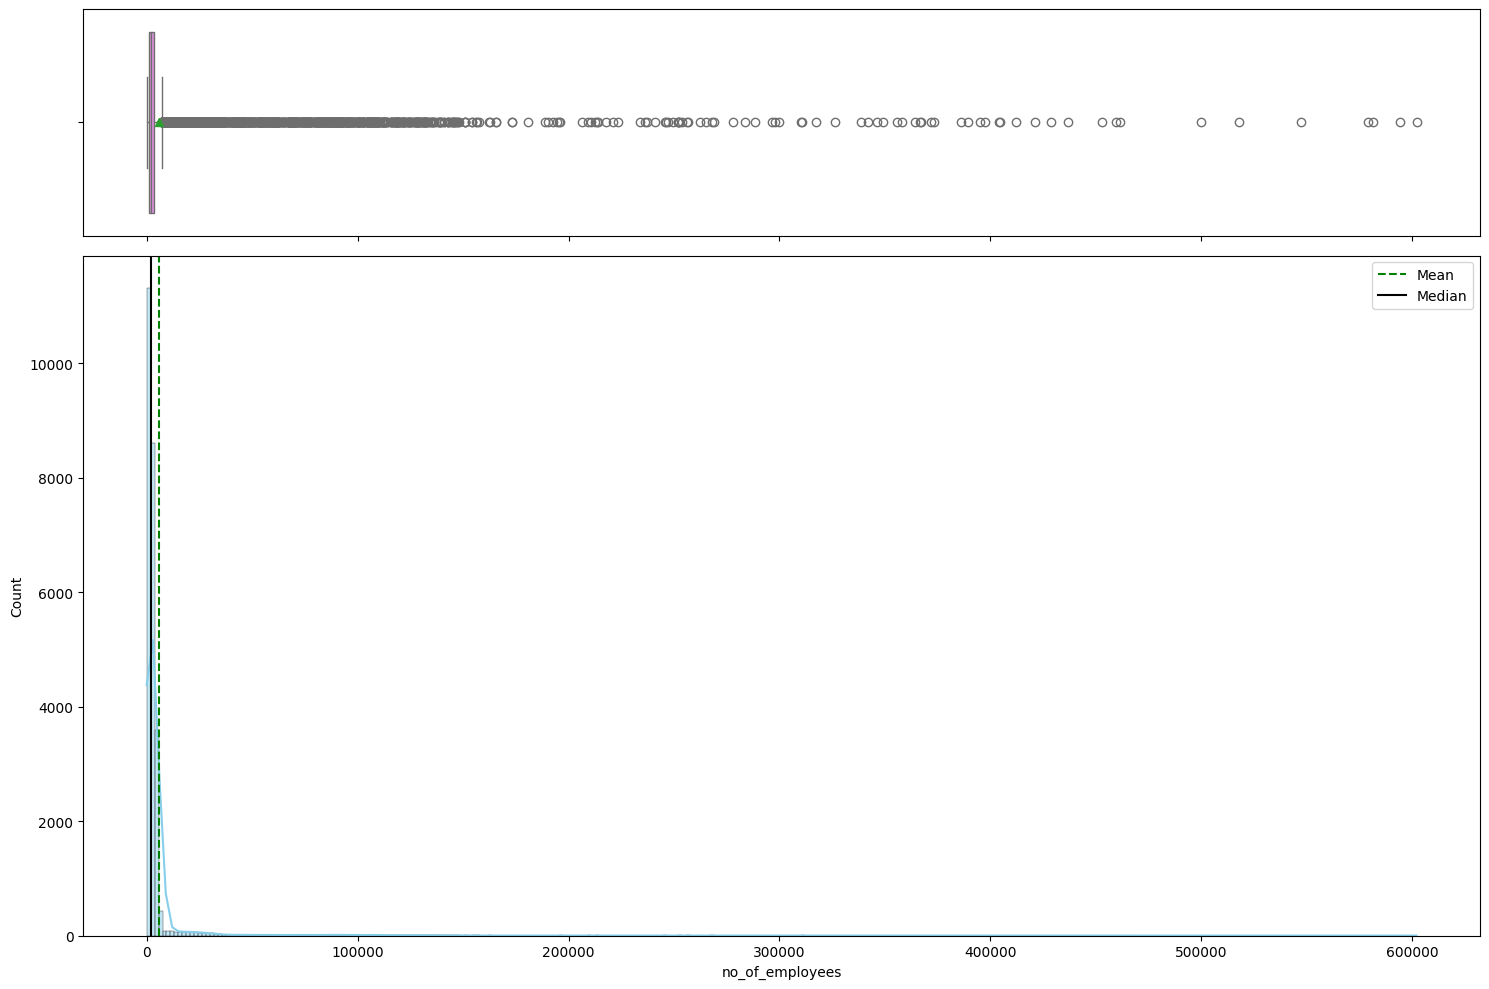

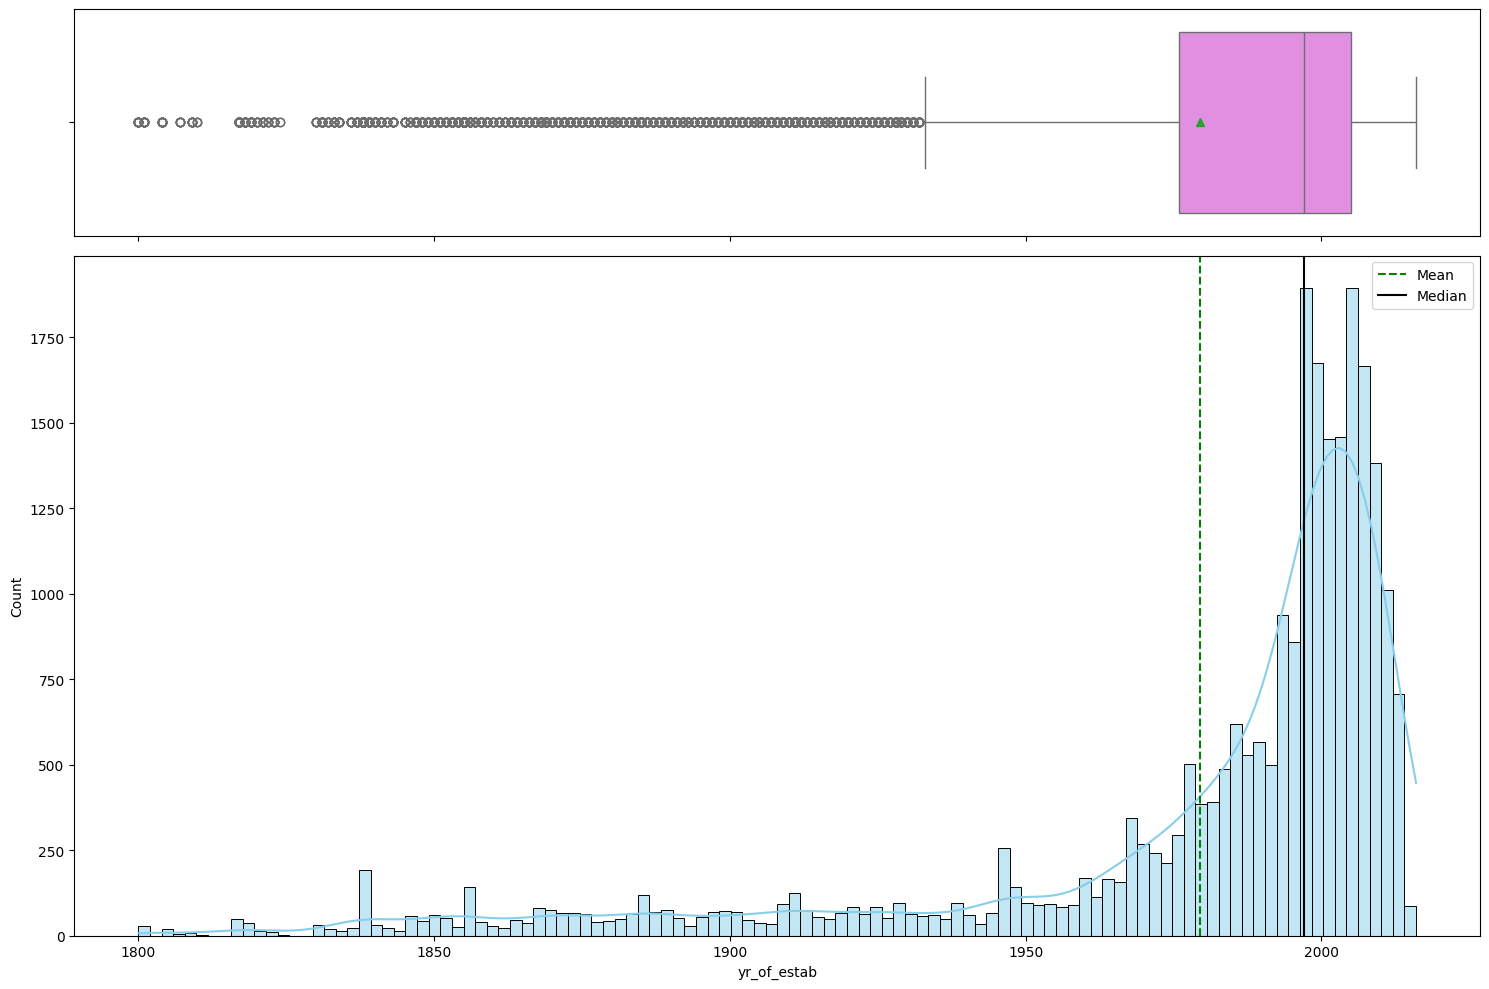

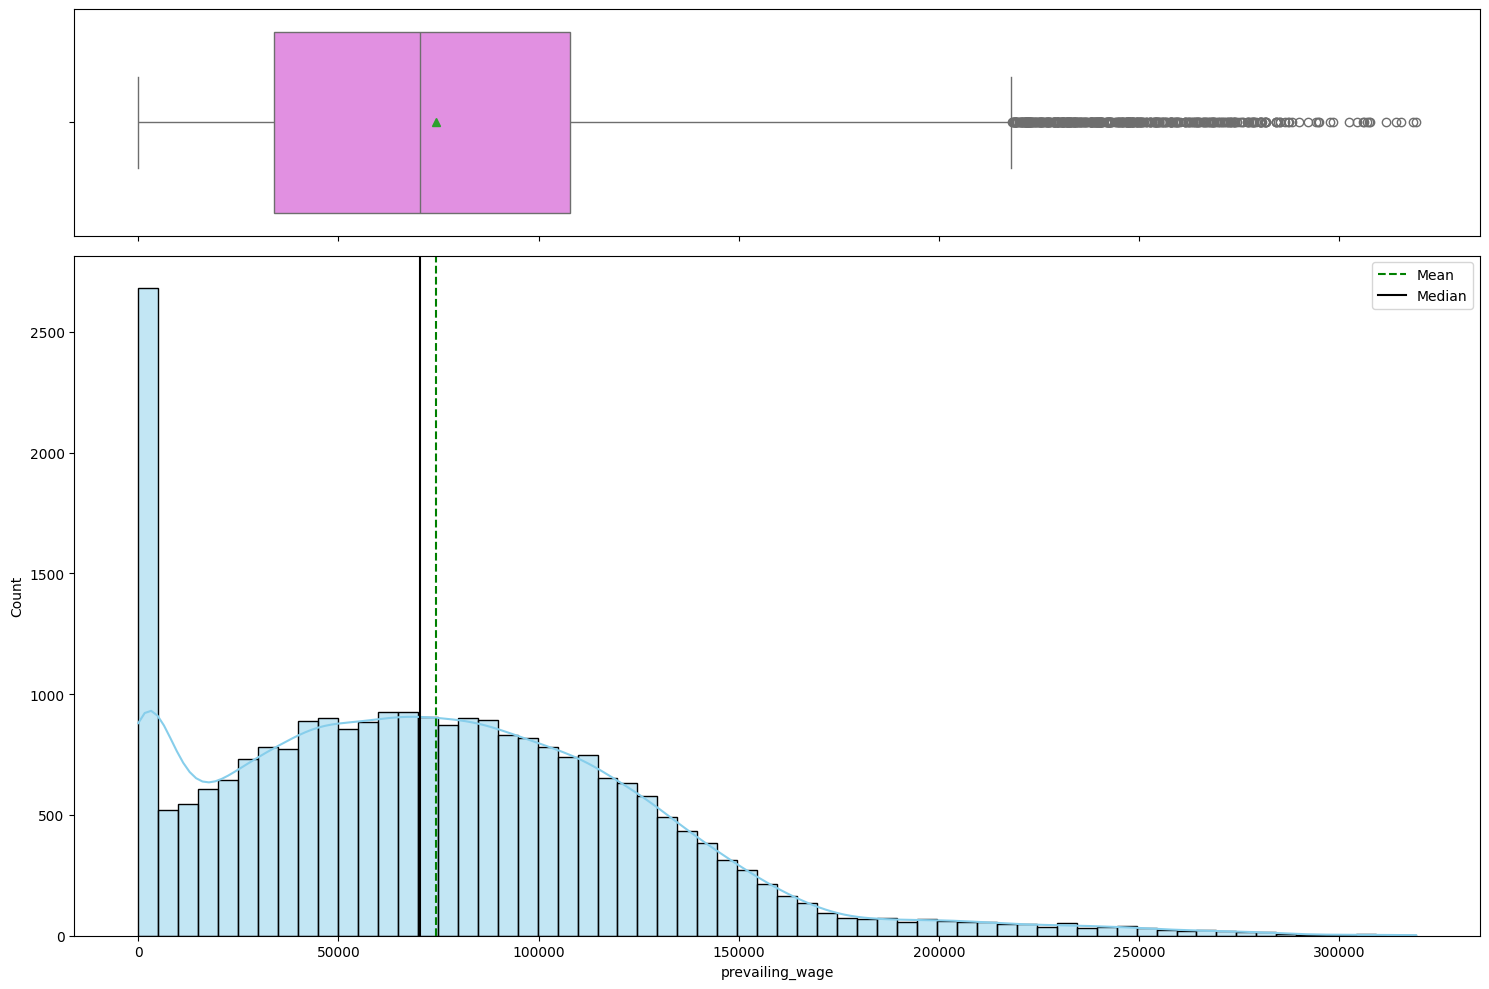

In [23]:
num_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

for col in num_cols:
    histogram_boxplot(df, col, kde=True)


## Insights from Histogram and Boxplot Visualizations:

In [25]:
def labeled_barplot(data, feature, perc=False, n=None, palette="Paired"):
    """
    Creates a barplot with labels showing either counts or percentages.

    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing the data.
    feature : str
        The categorical column to plot.
    perc : bool, optional
        Whether to display percentages instead of counts (default False).
    n : int, optional
        Display the top n categories (default None = show all).
    palette : str, optional
        Color palette for the bars (default "Paired").
    """
    
    total = len(data[feature])
    count = data[feature].nunique()
    plt.figure(figsize=(max(8, (n or count) + 2), 6))
    plt.xticks(rotation=45, fontsize=12)
    
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
        palette=palette
    )

    for p in ax.patches:
        if perc:
            label = f"{100 * p.get_height() / total:.1f}%"
        else:
            label = f"{p.get_height()}"
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(label, (x, y), ha="center", va="center", size=11, xytext=(0, 5), textcoords="offset points")
    
    ax.set_title(f"Distribution of {feature}", fontsize=14, fontweight='bold')
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel("Percentage" if perc else "Count", fontsize=12)
    
    plt.tight_layout()
    plt.show()


C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1748606210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


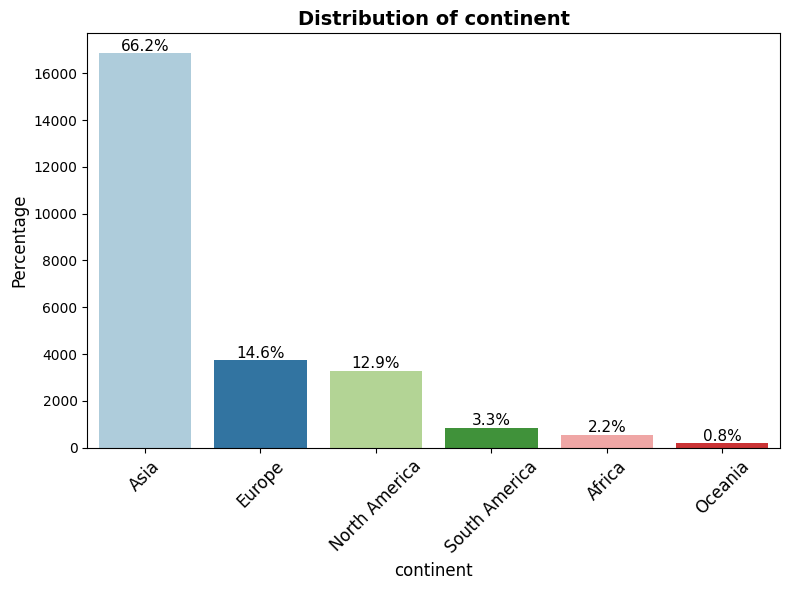

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1748606210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


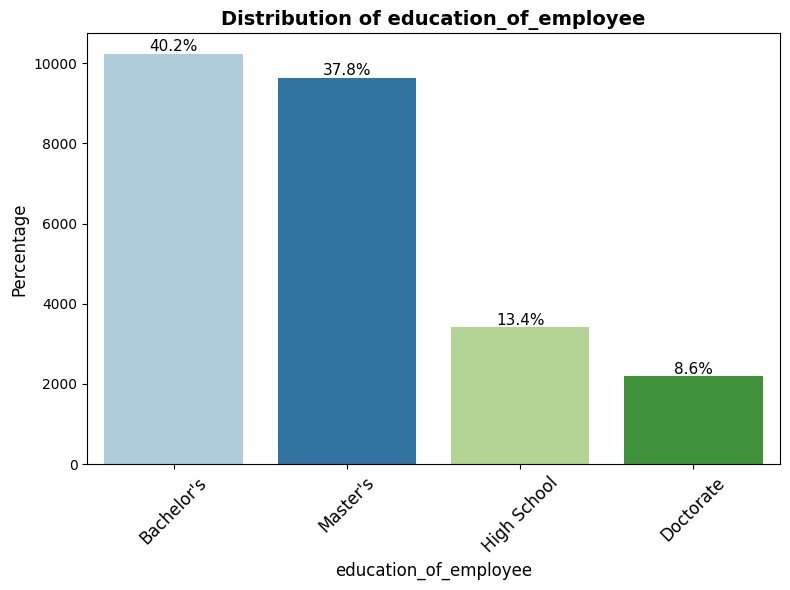

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1748606210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


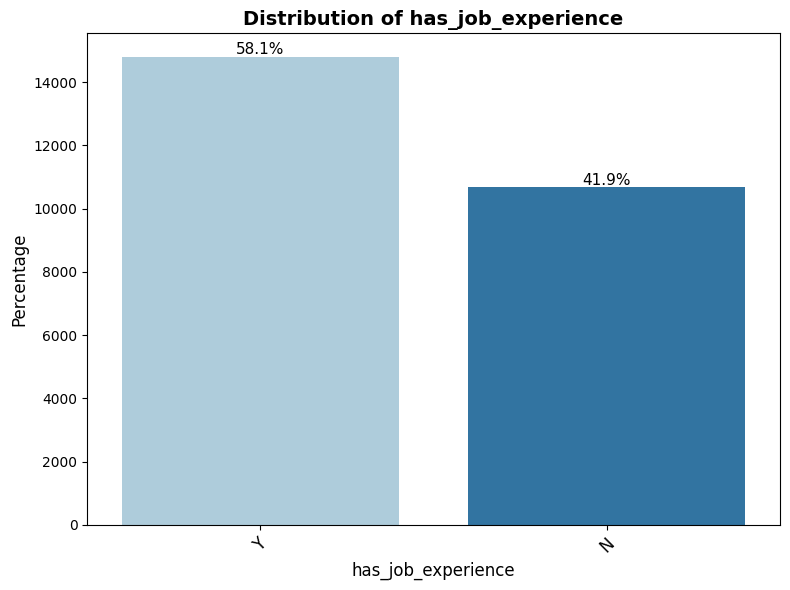

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1748606210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


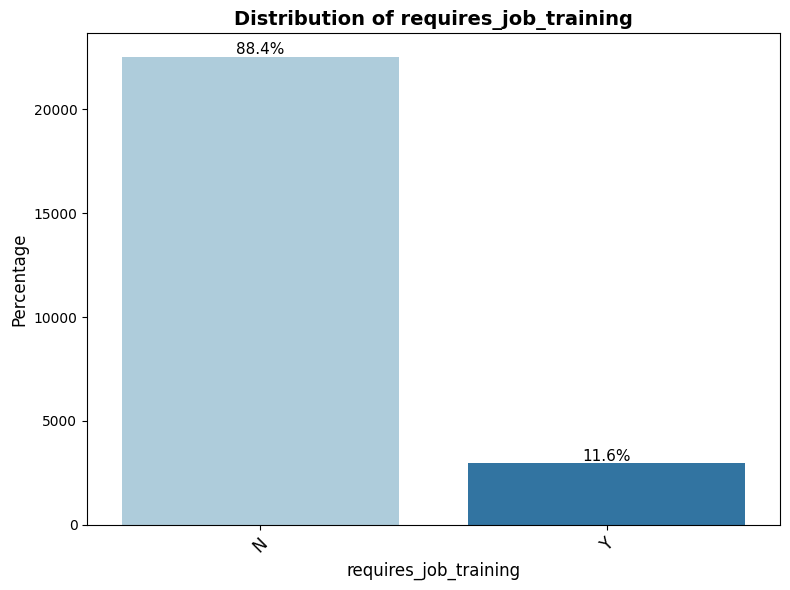

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1748606210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


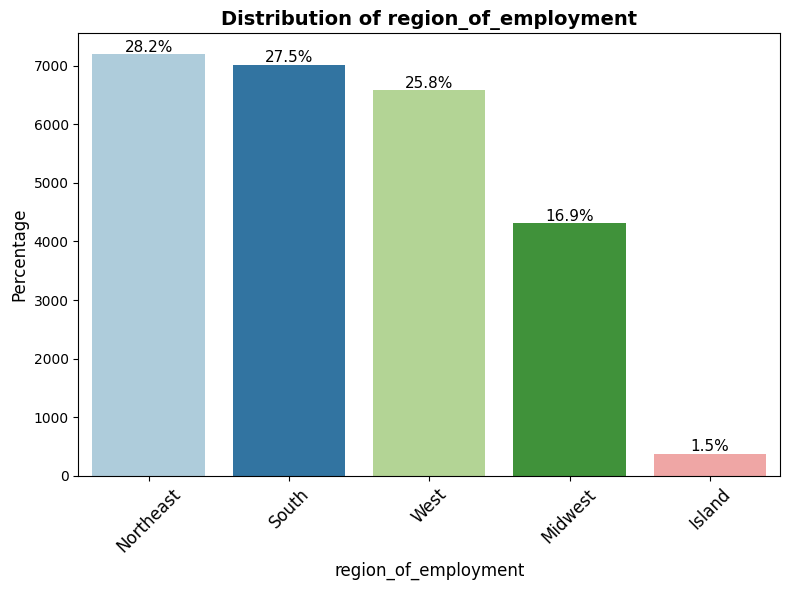

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1748606210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


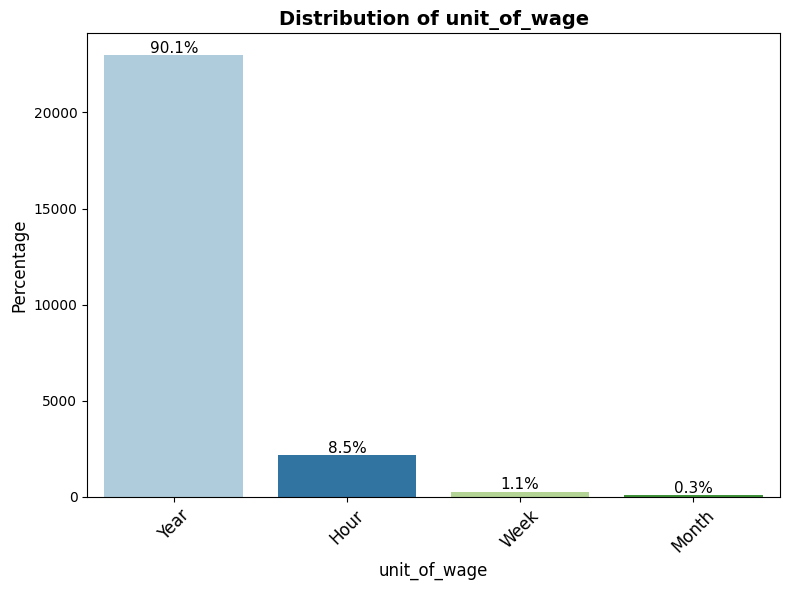

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1748606210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


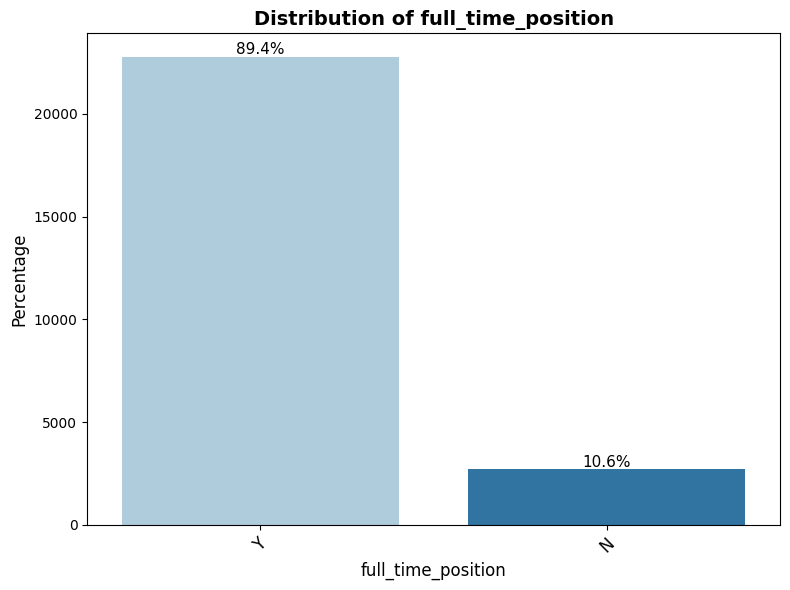

In [26]:
categorical_cols = ['continent', 'education_of_employee', 'has_job_experience',
                    'requires_job_training', 'region_of_employment',
                    'unit_of_wage', 'full_time_position']

for col in categorical_cols:
    labeled_barplot(df, col, perc=True)


## Bivariate Analyis

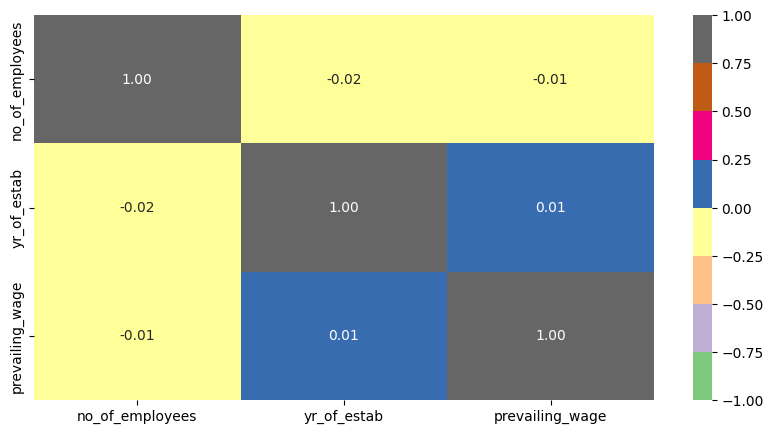

In [29]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Accent"
)
plt.show()

In [ ]:
def distribution_plot_wrt_target(data, predictor, target):
    """
    Plots distribution and boxplots of a numeric predictor with respect to a categorical target variable.

    Parameters:
    -----------
    data : pandas.DataFrame
        The dataset.
    predictor : str
        The numeric feature to analyze.
    target : str
        The categorical target variable (e.g., 'case_status').
    """

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    target_uniq = data[target].unique()

    # Histograms for each target class
    axs[0, 0].set_title(f"Distribution for {target} = {target_uniq[0]}")
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title(f"Distribution for {target} = {target_uniq[1]}")
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    # Boxplots
    axs[1, 0].set_title(f"Boxplot of {predictor} by {target}")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title(f"Boxplot of {predictor} by {target} (No Outliers)")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()


C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1117097169.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1117097169.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


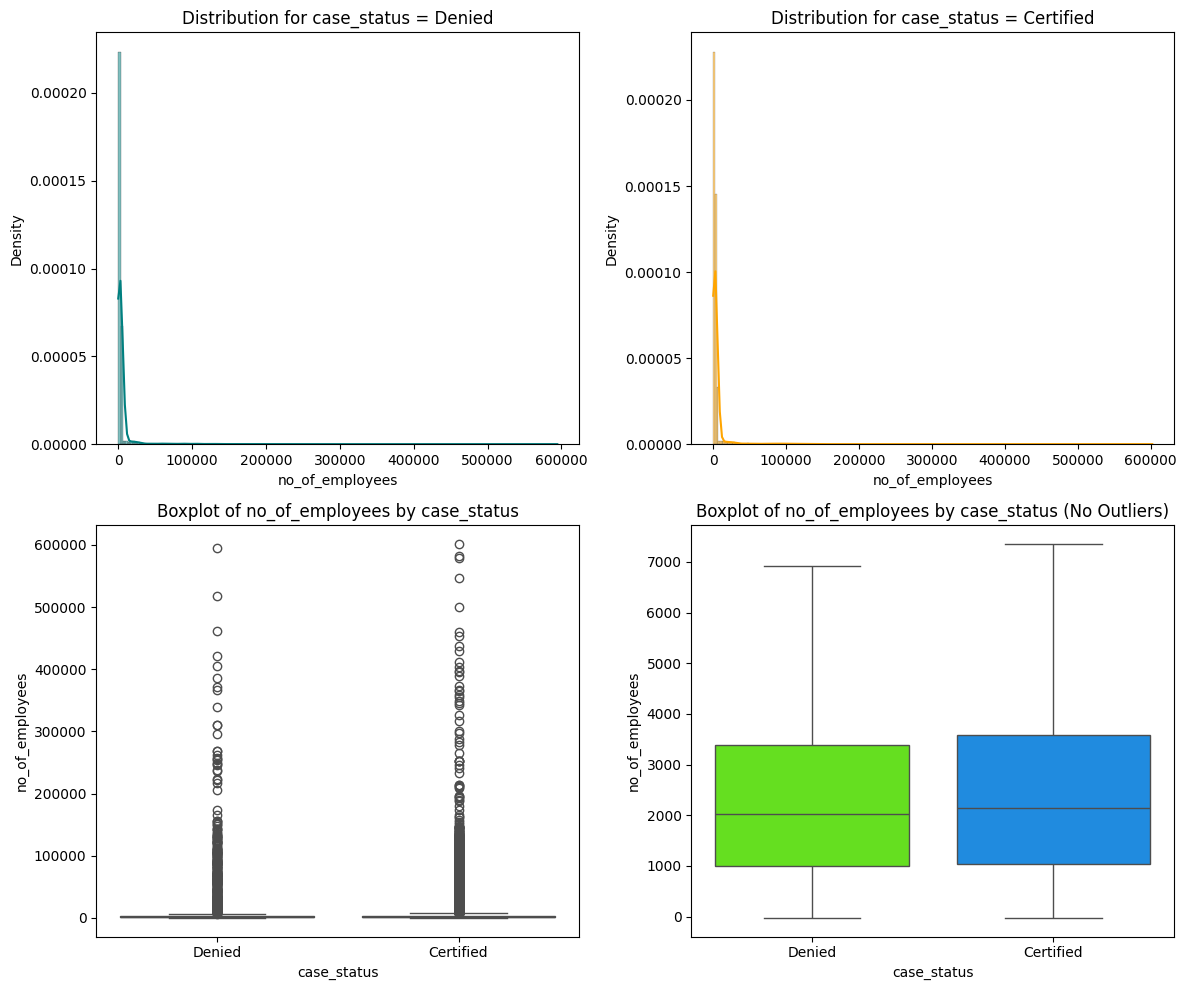

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1117097169.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1117097169.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


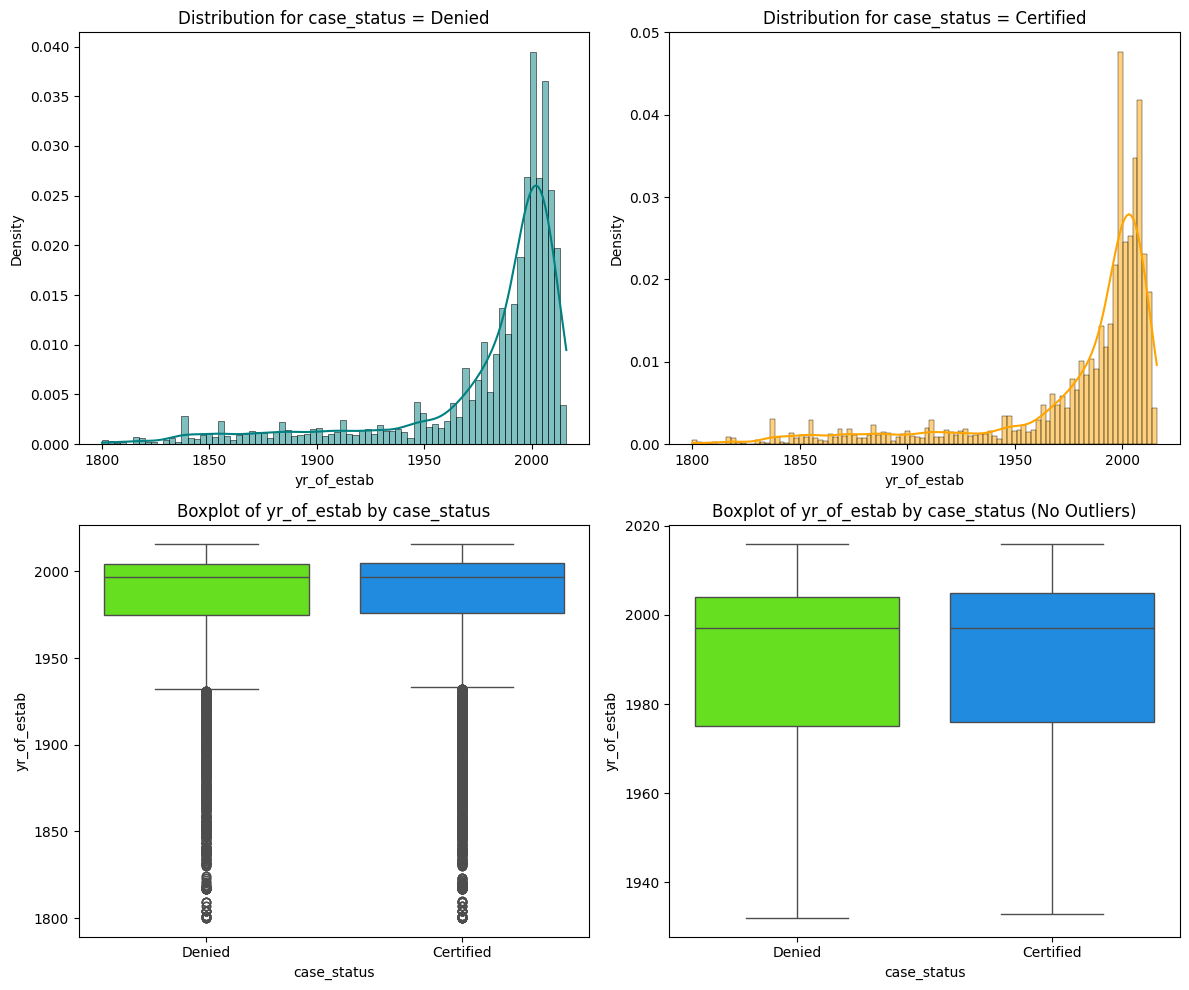

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1117097169.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1117097169.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


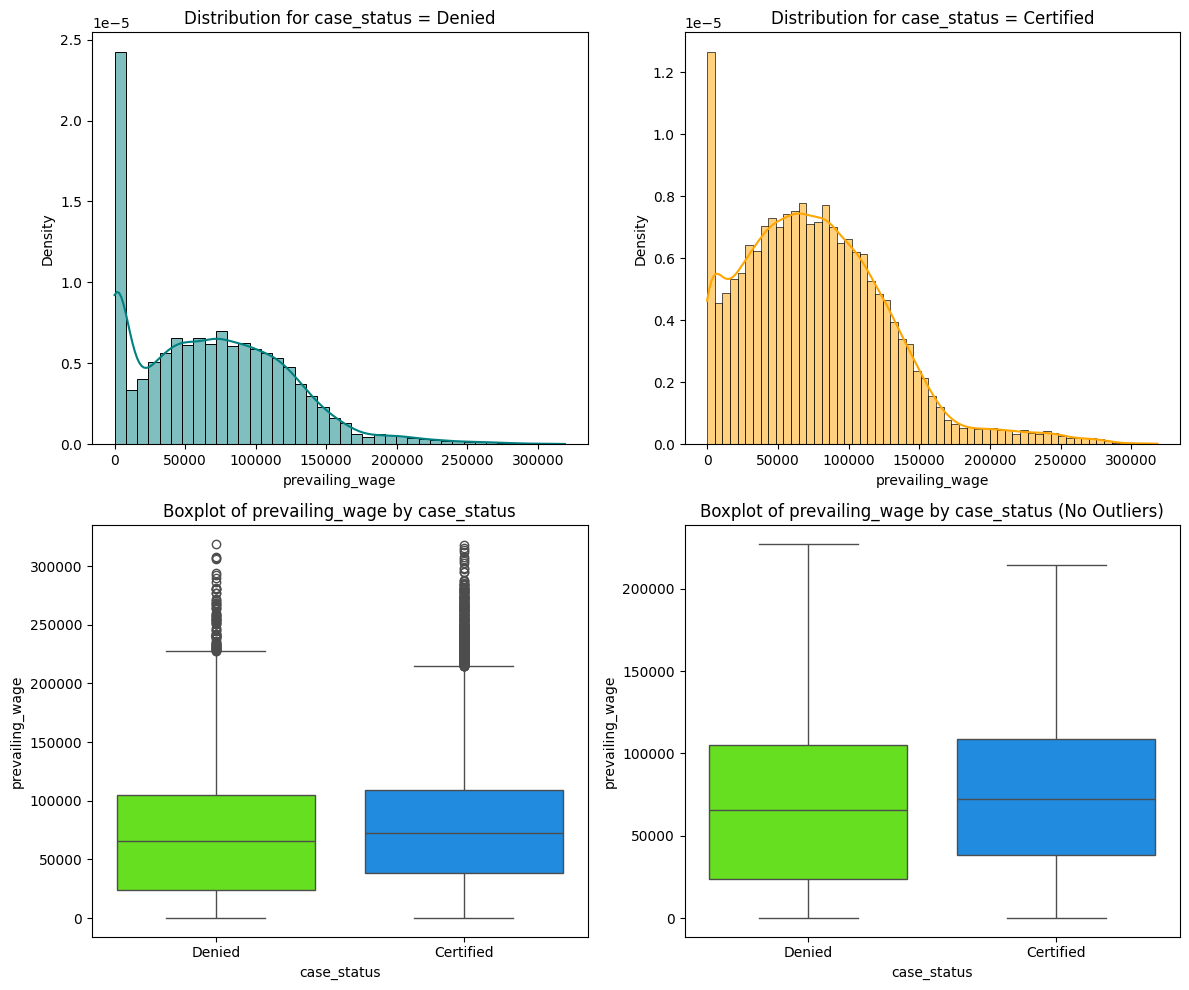

In [32]:
num_features = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

for feature in num_features:
    distribution_plot_wrt_target(df, feature, 'case_status')


## categorical bivariate analysis

In [35]:
def stacked_barplot(data, predictor, target):
    """
    Prints category counts and plots a stacked bar chart comparing the target distribution across predictor categories
    with distinct colors for clarity.
    """
    # Number of unique categories
    count = data[predictor].nunique()

    # Sort based on target frequency
    sorter = data[target].value_counts().index[-1]

    # Raw counts table
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(f"\nRaw Counts Crosstab for '{predictor}':")
    print(tab1)
    print("-" * 120)

    # Normalized proportions
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )

    # Define custom colors
    color_map = ["#1f77b4", "#ff7f0e"]  # blue and orange — strong contrast

    # Create the stacked barplot
    ax = tab.plot(
        kind="bar",
        stacked=True,
        figsize=(max(10, count + 5), 5),
        color=color_map,
        edgecolor="black",
        linewidth=1.2,
    )

    # Titles and labels
    plt.title(f"Distribution of {target} across {predictor}", fontsize=14, fontweight='bold')
    plt.ylabel("Proportion within Category", fontsize=12)
    plt.xlabel(predictor, fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=11)
    plt.yticks(fontsize=11)
    
    # Add grid for readability
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Legend
    plt.legend(title=target, loc="upper left", bbox_to_anchor=(1, 1), fontsize=11)
    
    plt.tight_layout()
    plt.show()



Raw Counts Crosstab for 'continent':
case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


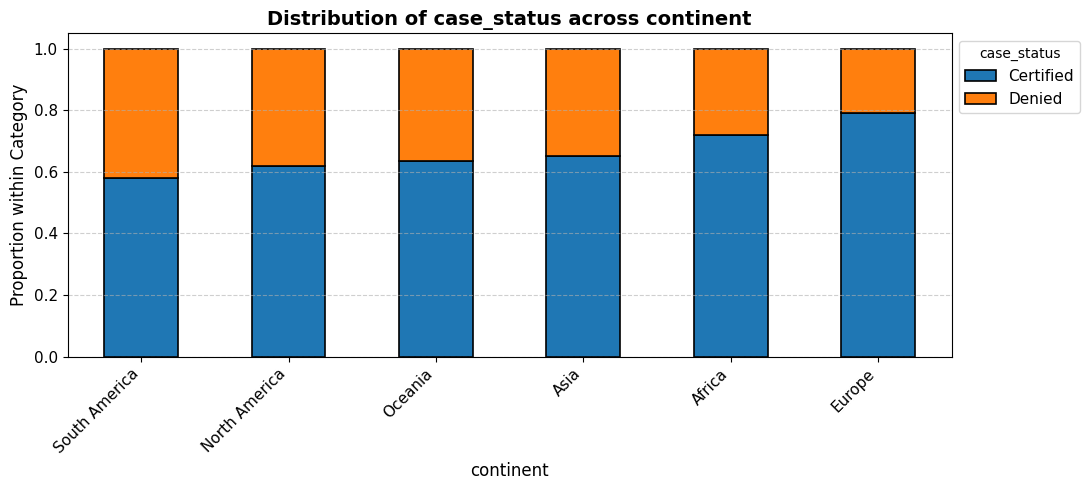


Raw Counts Crosstab for 'education_of_employee':
case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


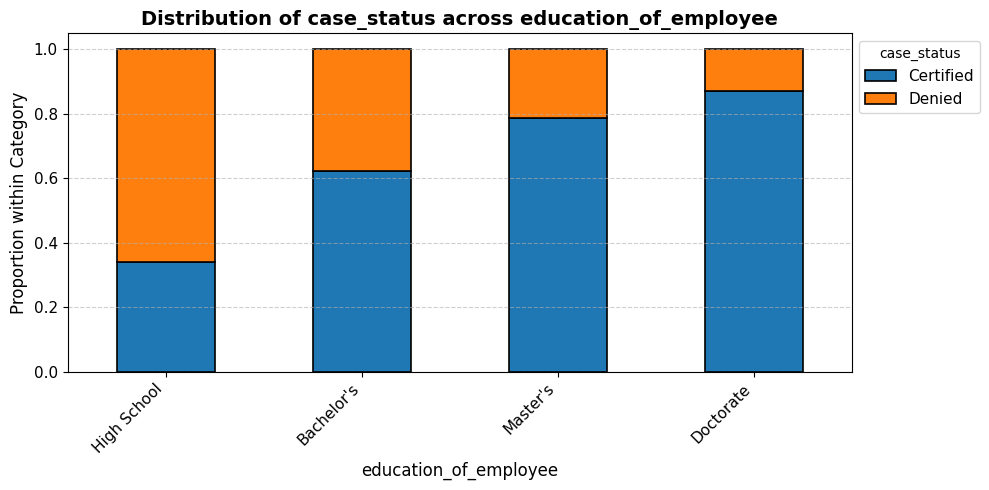


Raw Counts Crosstab for 'has_job_experience':
case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


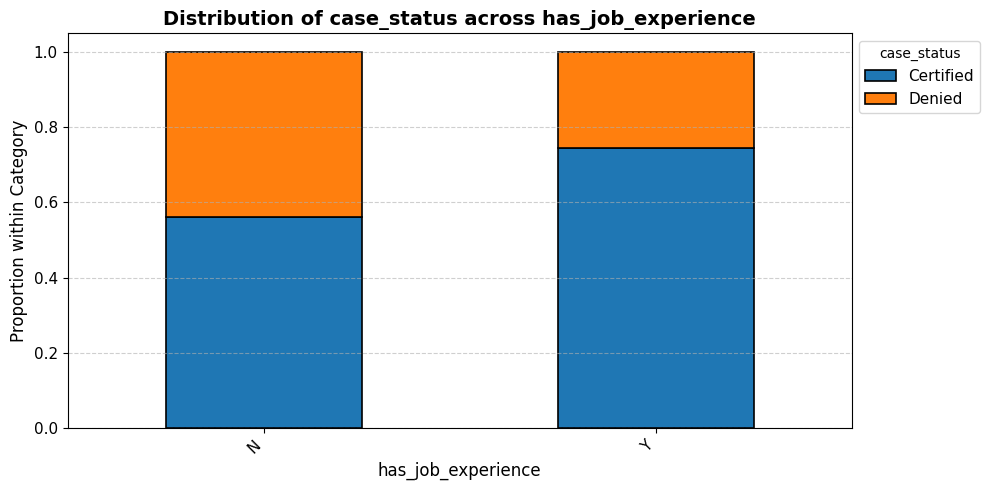


Raw Counts Crosstab for 'requires_job_training':
case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


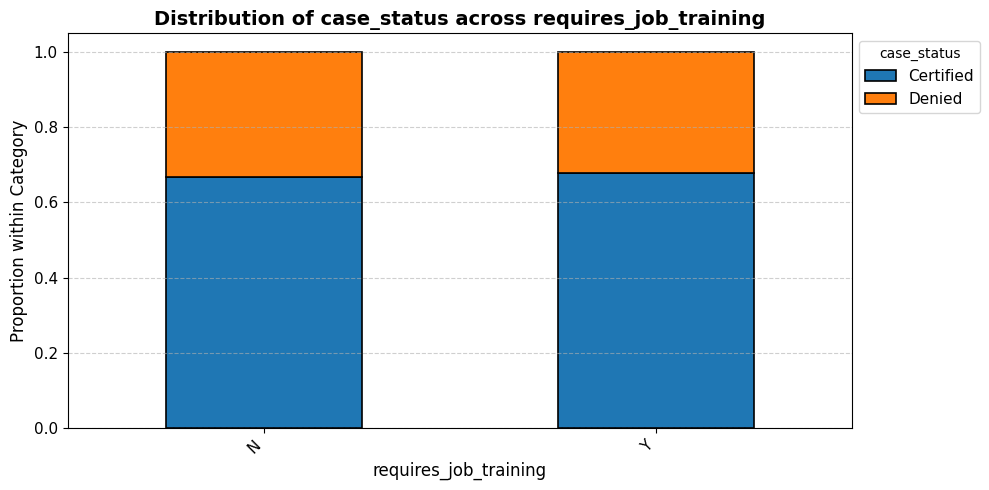


Raw Counts Crosstab for 'region_of_employment':
case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


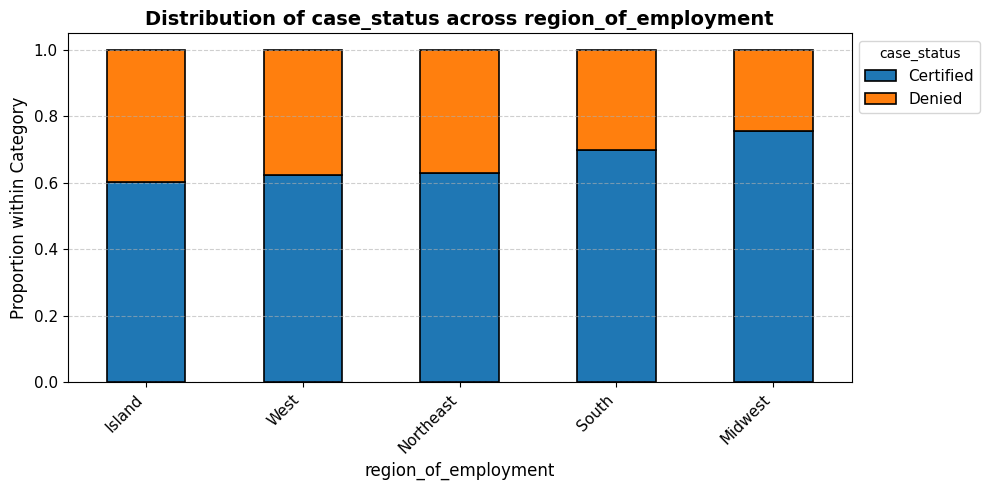


Raw Counts Crosstab for 'unit_of_wage':
case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


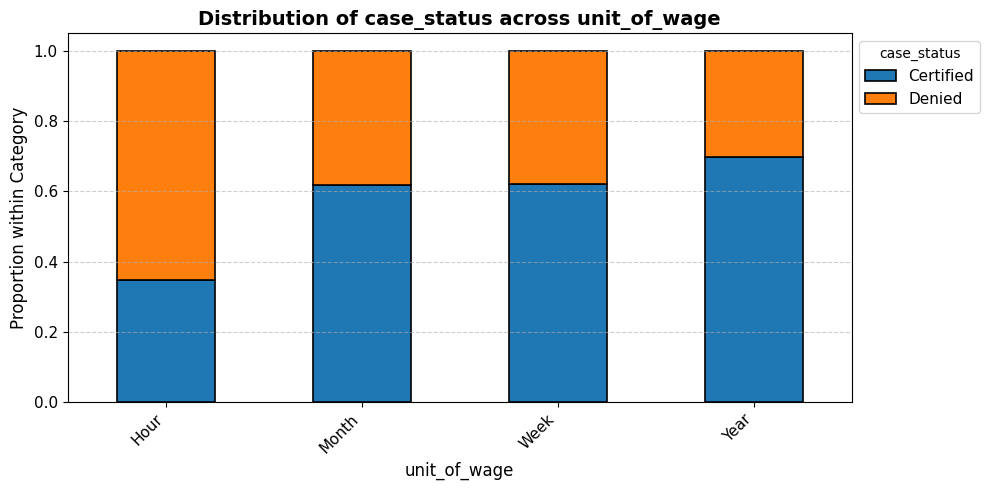


Raw Counts Crosstab for 'full_time_position':
case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


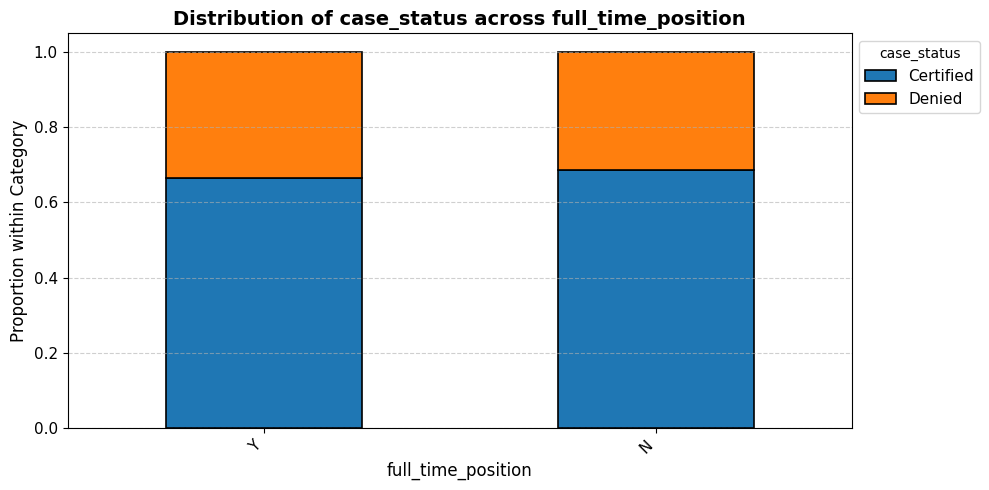

In [36]:
categorical_cols = [
    'continent',
    'education_of_employee',
    'has_job_experience',
    'requires_job_training',
    'region_of_employment',
    'unit_of_wage',
    'full_time_position'
]

for col in categorical_cols:
    stacked_barplot(df, col, 'case_status')


In [38]:
def boxplot_wrt_target(data, feature, target):
    """
    Creates a boxplot showing the distribution of a numeric feature with respect to a categorical target variable.
    """
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data, x=target, y=feature, palette=["#1f77b4", "#ff7f0e"], showmeans=True)
    plt.title(f'{feature} vs {target}', fontsize=14, fontweight='bold')
    plt.xlabel(target, fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1222025320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=feature, palette=["#1f77b4", "#ff7f0e"], showmeans=True)


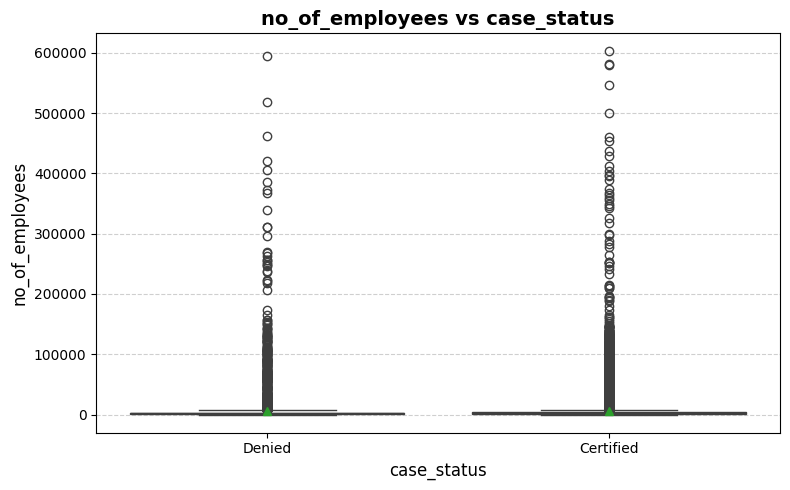

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1222025320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=feature, palette=["#1f77b4", "#ff7f0e"], showmeans=True)


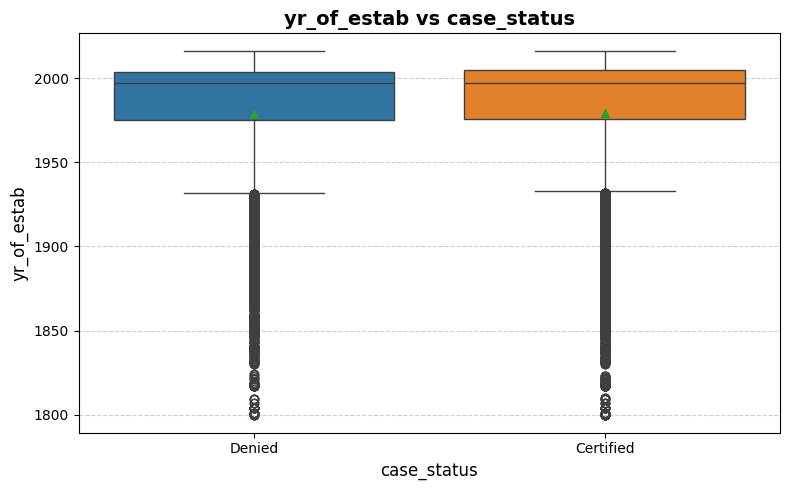

C:\Users\ncc\AppData\Local\Temp\ipykernel_14812\1222025320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=feature, palette=["#1f77b4", "#ff7f0e"], showmeans=True)


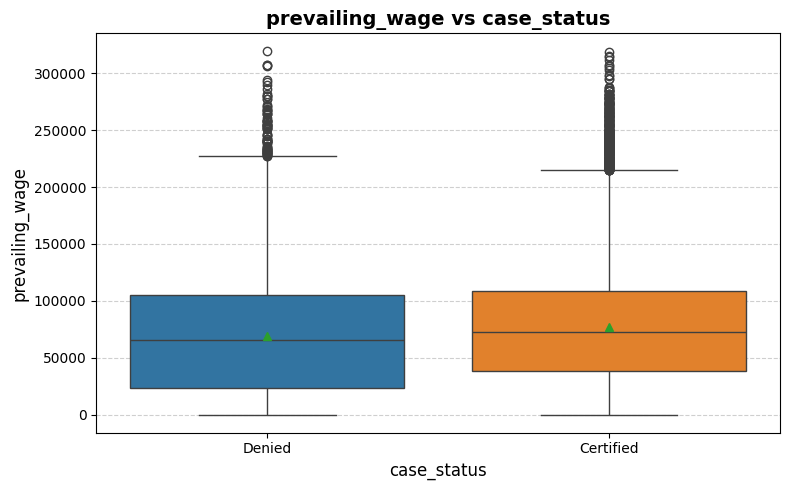

In [39]:
numeric_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

for col in numeric_cols:
    boxplot_wrt_target(df, col, 'case_status')
